### IMPORT LIBRARY

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

### LOAD DATASET

In [6]:
df = pd.read_csv("freelance_clean.csv")

In [7]:
df.head()

,source_dataset,record_type,original_id,title,description,skills,category,country,locality,experience_level,...,total_jobs,min_hourly_usd,max_hourly_usd,target_hourly_rate_usd,currency,rate_type,log_target_hourly_rate_usd,has_client_reviews,log_client_review_count,text_combined
0,freelancer_job_postings_cleaned,job_posting,37397423,virtual assistant / research assistant,Job Description: I am seeking a Virtual Assist...,"data entry, virtual assistant, web search, exc...",NaN,United States,unknown,NaN,...,NaN,5.0,15.0,10.0,USD,hourly,2.397895,0.0,0.000000,virtual assistant / research assistant Job Des...
1,freelancer_job_postings_cleaned,job_posting,37310844,database mangment,I am looking for a freelancer who can assist m...,"database administration, database development,...",NaN,Yemen,Tiaz,NaN,...,NaN,8.0,15.0,11.5,USD,hourly,2.525729,0.0,0.000000,database mangment I am looking for a freelance...
2,freelancer_job_postings_cleaned,job_posting,37310900,ai tool that scrapes data,I am looking for an experienced freelancer to ...,"python, web scraping, java, data mining, data ...",NaN,Switzerland,Zurich,NaN,...,NaN,15.0,25.0,20.0,USD,hourly,3.044522,0.0,0.000000,ai tool that scrapes data I am looking for an ...
3,freelancer_job_postings_cleaned,job_posting,37311659,sql and python trainer,Looking for an Advanced SQL and Python Trainer...,"python, sql, git, jenkins",NaN,United States,Aldie,NaN,...,NaN,2.0,8.0,5.0,USD,hourly,1.791759,0.0,0.000000,sql and python trainer Looking for an Advanced...
4,freelancer_job_postings_cleaned,job_posting,37318329,google sheets,I am looking for a freelancer who can help me ...,"google sheets, excel",NaN,United States,Merritt Island,NaN,...,NaN,15.0,25.0,20.0,USD,hourly,3.044522,1.0,1.386294,google sheets I am looking for a freelancer wh...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22200 entries, 0 to 22199
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   source_dataset              22200 non-null  object 
 1   record_type                 22200 non-null  object 
 2   original_id                 22200 non-null  object 
 3   title                       22200 non-null  object 
 4   description                 22200 non-null  object 
 5   skills                      17945 non-null  object 
 6   category                    21119 non-null  object 
 7   country                     22167 non-null  object 
 8   locality                    945 non-null    object 
 9   experience_level            19267 non-null  object 
 10  years_experience            0 non-null      float64
 11  client_rating               11433 non-null  float64
 12  client_review_count         22200 non-null  float64
 13  freelancer_rating           0 n

In [9]:
df.shape

(22200, 26)

## DROP INVALID COLUMNS

In [25]:
drop_cols = [
    "years_experience",
    "freelancer_rating",
    "job_success_pct",
    "total_hours",
    "total_jobs"
]

df = df.drop(columns=drop_cols)

## HANDLE MISSING VALUE

In [26]:
df = df.dropna(
    subset=["log_target_hourly_rate_usd"]
)

## EDA

### Distribusi category

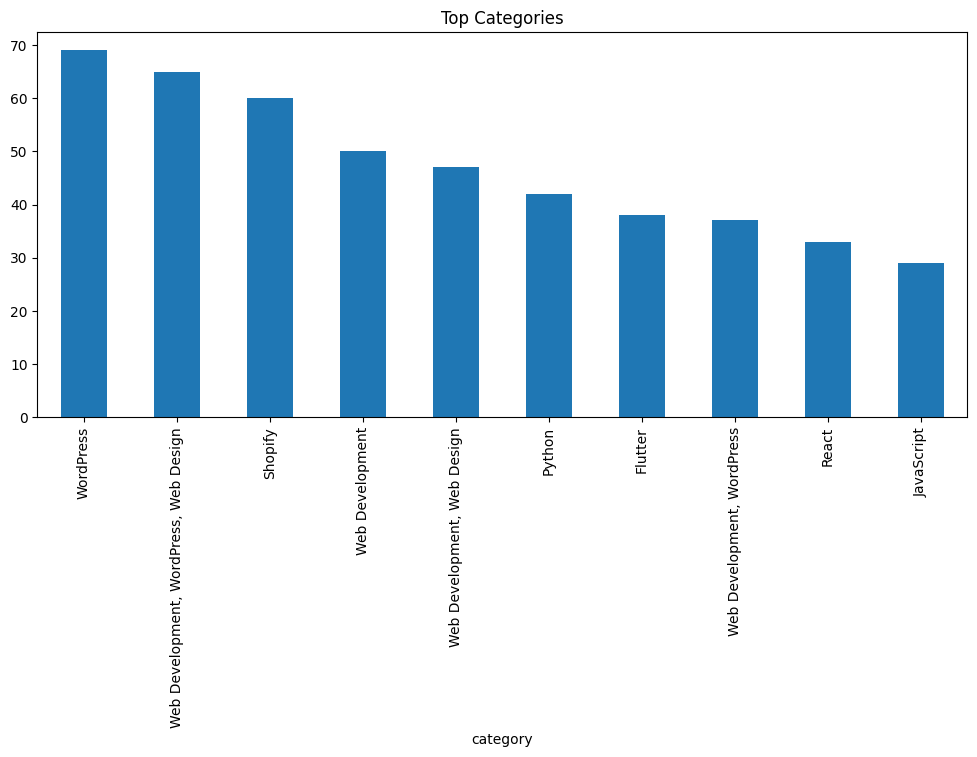

In [27]:
plt.figure(figsize=(12,5))

df["category"].value_counts().head(10).plot(kind="bar")

plt.title("Top Categories")
plt.show()

### Distribusi experience level

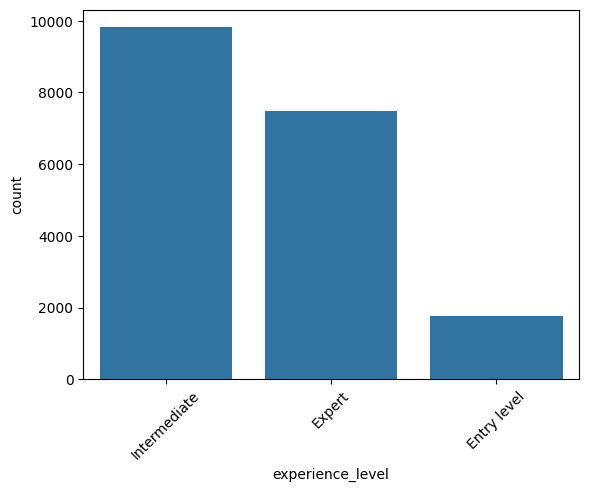

In [28]:
sns.countplot(
    data=df,
    x="experience_level"
)

plt.xticks(rotation=45)
plt.show()

### Missing value analysis

In [29]:
missing_ratio = (
    df.isnull().mean()
    .sort_values(ascending=False)
)

missing_ratio.head(20)

,0
locality,0.957333
client_rating,0.484580
skills,0.191048
experience_level,0.132414
category,0.048763
country,0.001410
description,0.000000
title,0.000000
original_id,0.000000
record_type,0.000000


## TARGET DISTRIBUTION & OUTLIER INSPECTION

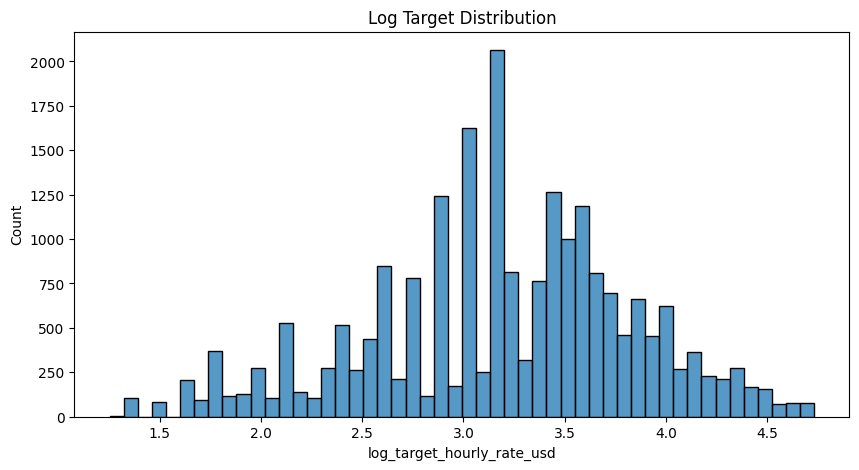

In [30]:
# Histogram target
plt.figure(figsize=(10,5))

sns.histplot(
    df["log_target_hourly_rate_usd"],
    bins=50
)

plt.title("Log Target Distribution")
plt.show()

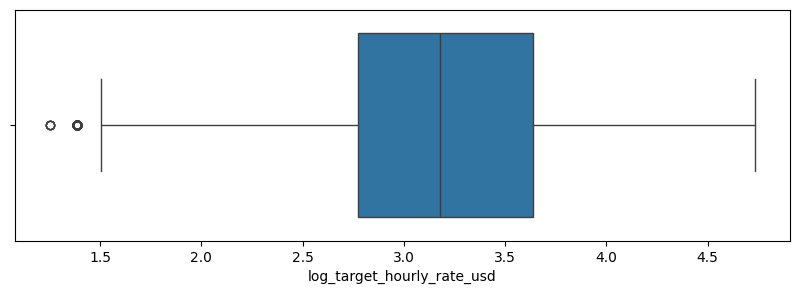

In [31]:
# Boxplot target
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df["log_target_hourly_rate_usd"]
)

plt.show()

In [32]:
# Quantile inspection
df["target_hourly_rate_usd"].quantile([
    0.90,
    0.95,
    0.99,
    0.995
])

,target_hourly_rate_usd
0.900,54.0
0.950,65.0
0.990,92.5
0.995,100.0


## FEATURE SELECTION

### TEXT FEATURE

In [34]:
text_feature = "text_combined"

### NUMERIC FEATURES

In [35]:
numeric_features = [
    "client_rating",
    "log_client_review_count",
    "has_client_reviews"
]

### CATEGORICAL FEATURES

In [36]:
categorical_features = [
    "category",
    "country",
    "experience_level"
]

## TARGET

In [37]:
y = df["log_target_hourly_rate_usd"]

## TRAIN TEST SPLIT

In [38]:
X = df[
    numeric_features +
    categorical_features +
    [text_feature]
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## TF-IDF VECTORIZATION (NLP)

In [39]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1,2),
    min_df=2
)

## PREPROCESSING PIPELINE

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "text",
            tfidf,
            text_feature
        ),

        (
            "num",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="median")
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            numeric_features
        ),

        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_features
        )
    ]
)

## BASELINE NLP REGRESSION MODEL

In [41]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

## TRAIN MODEL

In [42]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  TfidfVectorizer(max_features=5000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'),
                                                  'text_combined'),
                                                 ('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['client_rating',
                                                   'log_client_review_count',
                                                   'has_client_reviews']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['category', 'country',
                                                   'experience_level'])])),
                ('regressor', Ridge())])

## PREDICTION

In [43]:
y_pred = model.predict(X_test)

## EVALUATION

In [44]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 0.44024359311756567
RMSE: 0.5645258860299825
R2  : 0.2592071024185272


## ERROR ANALYSIS

In [45]:
results = X_test.copy()

results["actual"] = y_test
results["predicted"] = y_pred

results["error"] = abs(
    results["actual"] -
    results["predicted"]
)

results.sort_values(
    "error",
    ascending=False
).head(10)

,client_rating,log_client_review_count,has_client_reviews,category,country,experience_level,text_combined,actual,predicted,error
7324,5.000000,1.386294,1.0,"iOS Development, Web Development, Tech & IT, J...",United States,Expert,IT Tech for Livestream I’m looking for someone...,1.386294,3.843527,2.457232
350,5.000000,3.828641,1.0,NaN,Saudi Arabia,NaN,machine learning expert to extraction data and...,4.330733,2.267396,2.063337
18820,5.000000,2.079442,1.0,"Engineering & Architecture, Google Analytics, ...",Australia,Expert,Social Media Expert Australian Group We need a...,1.609438,3.523114,1.913676
20201,4.899758,4.110874,1.0,"PPC Campaign Setup & Management, Pay Per Click...",United Kingdom,Expert,Google Ads Call-Only Optimisation Looking for ...,1.609438,3.502259,1.892821
18660,5.000000,1.098612,1.0,"Administrative Support, Classifieds Posting, P...",Bangladesh,Expert,CLAD Genius Expert I Need Professional Clad Ge...,1.609438,3.490521,1.881083
8519,5.000000,1.098612,1.0,"Payment Gateway Integration, API, Payment Proc...",United States,Expert,Google pay payment gateway Greetings i would l...,1.609438,3.490069,1.880631
6626,2.454545,1.386294,1.0,"Web Development, API",Switzerland,Expert,"IT Developer Need a IT Developer, Framework PH...",1.386294,3.233711,1.847417
7679,3.373183,3.891820,1.0,"WordPress, PHP",Italy,Intermediate,Wordpress developer 500-1000 per month 3 dolla...,1.386294,3.233229,1.846935
18443,4.735562,1.945910,1.0,Campaign Setup,United States,Intermediate,Funnel To Capture email addresses Link already...,1.504077,3.346294,1.842216
17913,NaN,0.000000,0.0,"Sales & Marketing, Sales, Business Development...",Poland,Intermediate,IT Services Business Development( Commission B...,1.609438,3.449595,1.840157


KARENA MASIH BANYAK YANG KURANG OPTIMAL, KITA MEMBUAT BEBERAPA EKSPERIMEN UNTUK MEMBANDINGKAN.

## EKSPERIMEN A
## TITLE + SKILLS ONLY

In [49]:
# Buat text feature baru
df["text_title_skills"] = (
    df["title"].fillna("") + " " +
    df["skills"].fillna("")
)

# Definisikan fitur
text_feature_title_skills = "text_title_skills"

numeric_features_title_skills = [
    "client_rating",
    "log_client_review_count",
    "has_client_reviews"
]

categorical_features_title_skills = [
    "category",
    "country",
    "experience_level"
]

# Drop target null
df_title_skills = df.dropna(subset=["log_target_hourly_rate_usd"]).copy()

# Siapkan X dan y
X_title_skills = df_title_skills[
    numeric_features_title_skills +
    categorical_features_title_skills +
    [text_feature_title_skills]
]

y_title_skills = df_title_skills["log_target_hourly_rate_usd"]

# 5. Train-test split
X_train_title_skills, X_test_title_skills, y_train_title_skills, y_test_title_skills = train_test_split(
    X_title_skills,
    y_title_skills,
    test_size=0.2,
    random_state=42
)

# 6. Preprocessor
preprocessor_title_skills = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                stop_words="english",
                max_features=5000,
                ngram_range=(1, 2),
                min_df=2
            ),
            text_feature_title_skills
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features_title_skills
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features_title_skills
        )
    ]
)

# 7. Model
model_title_skills = Pipeline([
    ("preprocessor", preprocessor_title_skills),
    ("regressor", Ridge())
])

# 8. Train
model_title_skills.fit(X_train_title_skills, y_train_title_skills)

# 9. Predict
y_pred_title_skills = model_title_skills.predict(X_test_title_skills)

# 10. Evaluation
mae_title_skills = mean_absolute_error(y_test_title_skills, y_pred_title_skills)
rmse_title_skills = np.sqrt(mean_squared_error(y_test_title_skills, y_pred_title_skills))
r2_title_skills = r2_score(y_test_title_skills, y_pred_title_skills)

print("EXPERIMENT A — TITLE + SKILLS ONLY")
print("MAE :", mae_title_skills)
print("RMSE:", rmse_title_skills)
print("R2  :", r2_title_skills)

EXPERIMENT A — TITLE + SKILLS ONLY
MAE : 0.4544827370636792
RMSE: 0.5816082934606148
R2  : 0.2136963906481053


In [50]:
results_title_skills = X_test_title_skills.copy()

results_title_skills["actual"] = y_test_title_skills
results_title_skills["predicted"] = y_pred_title_skills

results_title_skills["error"] = abs(
    results_title_skills["actual"] -
    results_title_skills["predicted"]
)

results_title_skills.sort_values(
    "error",
    ascending=False
).head(10)

,client_rating,log_client_review_count,has_client_reviews,category,country,experience_level,text_title_skills,actual,predicted,error
7324,5.000000,1.386294,1.0,"iOS Development, Web Development, Tech & IT, J...",United States,Expert,IT Tech for Livestream iOS Development,1.386294,3.783873,2.397579
6626,2.454545,1.386294,1.0,"Web Development, API",Switzerland,Expert,IT Developer Developer,1.386294,3.459232,2.072938
2424,4.992724,2.197225,1.0,"Google Data Studio, Google Analytics, Google T...",United States,Expert,Google Analytics 4 setup and implementation Data,1.791759,3.764860,1.973101
2479,4.983523,2.197225,1.0,"Python, API, API Development, RESTful API, API...",United States,Intermediate,OpenAI Integration and API data,1.609438,3.574590,1.965152
7763,NaN,0.000000,0.0,"Mobile App Development, Web Development, Andro...",United States,Intermediate,Small mobile app similar to indeed website Mob...,1.609438,3.560810,1.951372
350,5.000000,3.828641,1.0,NaN,Saudi Arabia,NaN,machine learning expert to extraction data and...,4.330733,2.394258,1.936475
1353,NaN,0.000000,0.0,NaN,United States,Expert,Corrupted Data in Apache Open Office Spreadshe...,1.791759,3.669140,1.877380
16218,4.995425,2.944439,1.0,"Social Media Marketing, Instagram, Facebook, S...",India,Expert,Social media marketing marketing,4.483003,2.610877,1.872126
17557,4.450000,1.098612,1.0,Social Media Marketing,United States,Expert,Discord Server Promoter market,1.386294,3.224272,1.837978
8909,5.000000,1.386294,1.0,"PHP, API",United States,Intermediate,Need a full stack developer to write a script ...,1.386294,3.214729,1.828434


TERNYATA MENGHAPUS DESKRIPSI MALAH JADI TURUN PERFORMANYA HEHE<BR>
TAPI DI SINI SAYA LIHAT ADA YANG DOUBLE TOKEN, BISA DILIHAT BARIS KEDUA DI KOLOM `text_title_skills` ADA DUA KATA DEVELOPER DAN DI BARIS KEDELAPAN DI KOLOM YANG SAMA, TERDAPAT DUA KATA MARKETING. JADINYA BUAT EKSPERIMEN SELANJUTNYA KITA COBA BERSIHKAN DULU TEKSNYA AGAR TIDAK DOUBLE.

## EKSPERIMEN B
## CLEAN TEXT + MAX DF

In [51]:
import re

# Fungsi cleaning khusus Experiment B
def clean_text_light_b(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s+#.]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


# Buat dataframe khusus Experiment B
df_clean_text_b = df.dropna(
    subset=["log_target_hourly_rate_usd"]
).copy()


# Buat kolom text clean khusus Experiment B
df_clean_text_b["text_combined_clean_b"] = (
    df_clean_text_b["text_combined"]
    .fillna("")
    .apply(clean_text_light_b)
)


# Definisikan fitur khusus Experiment B
text_feature_clean_b = "text_combined_clean_b"

numeric_features_clean_b = [
    "client_rating",
    "log_client_review_count",
    "has_client_reviews"
]

categorical_features_clean_b = [
    "category",
    "country",
    "experience_level"
]


# Siapkan X dan y khusus Experiment B
X_clean_text_b = df_clean_text_b[
    numeric_features_clean_b +
    categorical_features_clean_b +
    [text_feature_clean_b]
]

y_clean_text_b = df_clean_text_b["log_target_hourly_rate_usd"]


# Train-test split khusus Experiment B
X_train_clean_text_b, X_test_clean_text_b, y_train_clean_text_b, y_test_clean_text_b = train_test_split(
    X_clean_text_b,
    y_clean_text_b,
    test_size=0.2,
    random_state=42
)


# Preprocessor khusus Experiment B
preprocessor_clean_text_b = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                stop_words="english",
                max_features=5000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.90
            ),
            text_feature_clean_b
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features_clean_b
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features_clean_b
        )
    ]
)


# Model khusus Experiment B
model_clean_text_b = Pipeline([
    ("preprocessor", preprocessor_clean_text_b),
    ("regressor", Ridge())
])


# Train
model_clean_text_b.fit(
    X_train_clean_text_b,
    y_train_clean_text_b
)


# Predict
y_pred_clean_text_b = model_clean_text_b.predict(
    X_test_clean_text_b
)


# Evaluation
mae_clean_text_b = mean_absolute_error(
    y_test_clean_text_b,
    y_pred_clean_text_b
)

rmse_clean_text_b = np.sqrt(
    mean_squared_error(
        y_test_clean_text_b,
        y_pred_clean_text_b
    )
)

r2_clean_text_b = r2_score(
    y_test_clean_text_b,
    y_pred_clean_text_b
)


print("EXPERIMENT B — CLEAN TEXT + max_df")
print("MAE :", mae_clean_text_b)
print("RMSE:", rmse_clean_text_b)
print("R2  :", r2_clean_text_b)

EXPERIMENT B — CLEAN TEXT + max_df
MAE : 0.4400014762395787
RMSE: 0.5643952658826613
R2  : 0.2595498724680403


In [52]:
results_clean_text_b = X_clean_text_b.copy()

results_clean_text_b["actual"] = y_clean_text_b
results_clean_text_b["predicted"] = y_clean_text_b

results_clean_text_b["error"] = abs(
    results_clean_text_b["actual"] -
    results_clean_text_b["predicted"]
)

results_clean_text_b.sort_values(
    "error",
    ascending=False
).head(10)

,client_rating,log_client_review_count,has_client_reviews,category,country,experience_level,text_combined_clean_b,actual,predicted,error
22182,4.423642,2.197225,1.0,"Marketing Strategy, Internet Marketing, Linked...",United Kingdom,Expert,linked in expert marketing expert required to ...,3.044522,3.044522,0.0
22181,4.762665,4.110874,1.0,"Social Media Marketing, Facebook, Facebook Adv...",United Kingdom,Intermediate,i need a facebook ig ad specialist hi i am cur...,2.740840,2.740840,0.0
22180,5.000000,1.386294,1.0,"Google Ads, Social Media Content Creation, Ins...",United States,Intermediate,need an honest skilled social media expert to ...,1.945910,1.945910,0.0
22179,4.718615,4.007333,1.0,"Internet Marketing, Social Media Marketing, Ma...",United States,Intermediate,creating click funnels for online product i am...,2.708050,2.708050,0.0
22178,4.751429,4.060443,1.0,"Marketing Strategy, Brand Guidelines, SEO Keyw...",United States,Intermediate,digital marketing manager who you are you poss...,2.140066,2.140066,0.0
22177,4.921264,4.644391,1.0,"Retail & Consumer Goods, Business with 10-99 E...",United States,Expert,product manager project manager to work with m...,4.248495,4.248495,0.0
22176,NaN,0.000000,0.0,"Real Estate, Lead Generation, Web Development",United States,Expert,lead generation website development houston re...,3.044522,3.044522,0.0
22175,NaN,0.000000,0.0,"Social Media Marketing, Instagram Marketing, F...",United States,Intermediate,remote social media manager content creator ar...,2.140066,2.140066,0.0
22174,5.000000,1.098612,1.0,"Cold Calling, Scheduling, Telemarketing, Lead ...",Singapore,Intermediate,cold caller appointment setter looking for som...,2.140066,2.140066,0.0
22173,NaN,0.000000,0.0,"Social Media Marketing, Creative Writing, Cont...",United States,Entry level,content creator need help filming 1 minute pro...,2.708050,2.708050,0.0


WALAUPUN ADA BEBERAPA YANG ERRORNYA 0, TAPI MASIH BANYAK KEMUNGKINAN YANG TERJADI. SEPERTI POTENSIAL LEAKAGE YANG ARTINYA ADA INFORMASI TARGET TERSEMBUNYI DALAM TEXT. <BR>
KESIMPULAN:
1. CLEANING RINGAN TIDAK BANYAK MEMBANTU
2. DESKRIPSI TETAP MEMBAWA SIGNAL
3. TF-IDF MULAI MENCAPAI LIMIT REPRESENTASI
<BR>
SEKARANG KITA BISA COBA EKSPERIMEN TERAKHIR SEBELUM BERALIH MODEL

## EKSPERIMEN C
## NON NLP

In [53]:


# Buat dataframe khusus Experiment C
df_no_nlp = df.dropna(
    subset=["log_target_hourly_rate_usd"]
).copy()


# Definisikan fitur khusus Experiment C
numeric_features_no_nlp = [
    "client_rating",
    "log_client_review_count",
    "has_client_reviews"
]

categorical_features_no_nlp = [
    "category",
    "country",
    "experience_level"
]


# Siapkan X dan y khusus Experiment C
X_no_nlp = df_no_nlp[
    numeric_features_no_nlp +
    categorical_features_no_nlp
]

y_no_nlp = df_no_nlp["log_target_hourly_rate_usd"]


# Train-test split khusus Experiment C
X_train_no_nlp, X_test_no_nlp, y_train_no_nlp, y_test_no_nlp = train_test_split(
    X_no_nlp,
    y_no_nlp,
    test_size=0.2,
    random_state=42
)


# Preprocessor tanpa NLP
preprocessor_no_nlp = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features_no_nlp
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features_no_nlp
        )
    ]
)


# Model tanpa NLP
model_no_nlp = Pipeline([
    ("preprocessor", preprocessor_no_nlp),
    ("regressor", Ridge())
])


# Train
model_no_nlp.fit(
    X_train_no_nlp,
    y_train_no_nlp
)


# Predict
y_pred_no_nlp = model_no_nlp.predict(
    X_test_no_nlp
)


# Evaluation
mae_no_nlp = mean_absolute_error(
    y_test_no_nlp,
    y_pred_no_nlp
)

rmse_no_nlp = np.sqrt(
    mean_squared_error(
        y_test_no_nlp,
        y_pred_no_nlp
    )
)

r2_no_nlp = r2_score(
    y_test_no_nlp,
    y_pred_no_nlp
)


print("EXPERIMENT C — NO NLP")
print("MAE :", mae_no_nlp)
print("RMSE:", rmse_no_nlp)
print("R2  :", r2_no_nlp)

EXPERIMENT C — NO NLP
MAE : 0.4850667557856968
RMSE: 0.6155952384850905
R2  : 0.11911423537919752


In [58]:
results_no_nlp = X_no_nlp.copy()

results_no_nlp["actual"] = y_no_nlp
results_no_nlp["predicted"] = y_no_nlp

results_no_nlp["error"] = abs(
    results_no_nlp["actual"] -
    results_no_nlp["predicted"]
)

results_no_nlp.sort_values(
    "error",
    ascending=False
).head(10)

,client_rating,log_client_review_count,has_client_reviews,category,country,experience_level,actual,predicted,error
22182,4.423642,2.197225,1.0,"Marketing Strategy, Internet Marketing, Linked...",United Kingdom,Expert,3.044522,3.044522,0.0
22181,4.762665,4.110874,1.0,"Social Media Marketing, Facebook, Facebook Adv...",United Kingdom,Intermediate,2.740840,2.740840,0.0
22180,5.000000,1.386294,1.0,"Google Ads, Social Media Content Creation, Ins...",United States,Intermediate,1.945910,1.945910,0.0
22179,4.718615,4.007333,1.0,"Internet Marketing, Social Media Marketing, Ma...",United States,Intermediate,2.708050,2.708050,0.0
22178,4.751429,4.060443,1.0,"Marketing Strategy, Brand Guidelines, SEO Keyw...",United States,Intermediate,2.140066,2.140066,0.0
22177,4.921264,4.644391,1.0,"Retail & Consumer Goods, Business with 10-99 E...",United States,Expert,4.248495,4.248495,0.0
22176,NaN,0.000000,0.0,"Real Estate, Lead Generation, Web Development",United States,Expert,3.044522,3.044522,0.0
22175,NaN,0.000000,0.0,"Social Media Marketing, Instagram Marketing, F...",United States,Intermediate,2.140066,2.140066,0.0
22174,5.000000,1.098612,1.0,"Cold Calling, Scheduling, Telemarketing, Lead ...",Singapore,Intermediate,2.140066,2.140066,0.0
22173,NaN,0.000000,0.0,"Social Media Marketing, Creative Writing, Cont...",United States,Entry level,2.708050,2.708050,0.0


## TABEL EKSPERIMEN FINAL !!

In [60]:
experiment_results = pd.DataFrame({
    "experiment": [
        "No NLP",
        "Baseline NLP",
        "Title + Skills",
        "Clean Text + max_df"
    ],
    "MAE": [
        mae_no_nlp,
        mae,
        mae_title_skills,
        mae_clean_text_b
    ],
    "RMSE": [
        rmse_no_nlp,
        rmse,
        rmse_title_skills,
        rmse_clean_text_b
    ],
    "R2": [
        r2_no_nlp,
        r2,
        r2_title_skills,
        r2_clean_text_b
    ]
})

experiment_results.sort_values(
    "R2",
    ascending=False
)

,experiment,MAE,RMSE,R2
3,Clean Text + max_df,0.440001,0.564395,0.259550
1,Baseline NLP,0.440244,0.564526,0.259207
2,Title + Skills,0.454483,0.581608,0.213696
0,No NLP,0.485067,0.615595,0.119114


## PAKAI MODEL LinearSVR

In [61]:
from sklearn.svm import LinearSVR

df_linearsvr = df.dropna(
    subset=["log_target_hourly_rate_usd"]
).copy()

# Definisi Fitur
text_feature_linearsvr = "text_combined"

numeric_features_linearsvr = [
    "client_rating",
    "log_client_review_count",
    "has_client_reviews"
]

categorical_features_linearsvr = [
    "category",
    "country",
    "experience_level"
]

# Siapkan X dan y
X_linearsvr = df_linearsvr[
    numeric_features_linearsvr +
    categorical_features_linearsvr +
    [text_feature_linearsvr]
]

y_linearsvr = df_linearsvr[
    "log_target_hourly_rate_usd"
]

# Train Test Split

X_train_linearsvr, X_test_linearsvr, y_train_linearsvr, y_test_linearsvr = train_test_split(
    X_linearsvr,
    y_linearsvr,
    test_size=0.2,
    random_state=42
)

# Preprocessor

preprocessor_linearsvr = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                stop_words="english",
                max_features=5000,
                ngram_range=(1,2),
                min_df=2
            ),
            text_feature_linearsvr
        ),

        (
            "num",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="median")
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            numeric_features_linearsvr
        ),

        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_features_linearsvr
        )
    ]
)

# Buat MODEL LinearSVR
model_linearsvr = Pipeline([
    (
        "preprocessor",
        preprocessor_linearsvr
    ),

    (
        "regressor",
        LinearSVR(
            random_state=42,
            max_iter=5000
        )
    )
])

# Train MODEL
model_linearsvr.fit(
    X_train_linearsvr,
    y_train_linearsvr
)

# Predict
y_pred_linearsvr = model_linearsvr.predict(
    X_test_linearsvr
)

# Evaluasi
mae_linearsvr = mean_absolute_error(
    y_test_linearsvr,
    y_pred_linearsvr
)

rmse_linearsvr = np.sqrt(
    mean_squared_error(
        y_test_linearsvr,
        y_pred_linearsvr
    )
)

r2_linearsvr = r2_score(
    y_test_linearsvr,
    y_pred_linearsvr
)

print("EXPERIMENT D — LinearSVR")
print("MAE :", mae_linearsvr)
print("RMSE:", rmse_linearsvr)
print("R2  :", r2_linearsvr)


EXPERIMENT D — LinearSVR
MAE : 0.4536855240903262
RMSE: 0.5810701342839435
R2  : 0.2151508428473088


In [63]:
experiment_results = pd.DataFrame({
    "experiment": [
        "No NLP",
        "Baseline Ridge",
        "Title + Skills",
        "Clean Text + max_df",
        "LinearSVR"
    ],

    "MAE": [
        mae_no_nlp,
        mae,
        mae_title_skills,
        mae_clean_text_b,
        mae_linearsvr
    ],

    "RMSE": [
        rmse_no_nlp,
        rmse,
        rmse_title_skills,
        rmse_clean_text_b,
        rmse_linearsvr
    ],

    "R2": [
        r2_no_nlp,
        r2,
        r2_title_skills,
        r2_clean_text_b,
        r2_linearsvr
    ]
})

experiment_results.sort_values(
    "R2",
    ascending=False
)

,experiment,MAE,RMSE,R2
3,Clean Text + max_df,0.440001,0.564395,0.259550
1,Baseline Ridge,0.440244,0.564526,0.259207
4,LinearSVR,0.453686,0.581070,0.215151
2,Title + Skills,0.454483,0.581608,0.213696
0,No NLP,0.485067,0.615595,0.119114


## EKSPERIMEN E
## XBGoost

In [64]:
from xgboost import XGBRegressor

# Buat dataframe khusus XGBoost
df_xgb = df.dropna(
    subset=["log_target_hourly_rate_usd"]
).copy()


# Buat clean text khusus XGBoost
df_xgb["text_combined_clean_xgb"] = (
    df_xgb["text_combined"]
    .fillna("")
    .apply(clean_text_light_b)
)


# Definisikan fitur
text_feature_xgb = "text_combined_clean_xgb"

numeric_features_xgb = [
    "client_rating",
    "log_client_review_count",
    "has_client_reviews"
]

categorical_features_xgb = [
    "category",
    "country",
    "experience_level"
]


# Siapkan X dan y
X_xgb = df_xgb[
    numeric_features_xgb +
    categorical_features_xgb +
    [text_feature_xgb]
]

y_xgb = df_xgb["log_target_hourly_rate_usd"]


# Train-test split
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb,
    y_xgb,
    test_size=0.2,
    random_state=42
)


# Preprocessor
preprocessor_xgb = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                stop_words="english",
                max_features=3000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.90
            ),
            text_feature_xgb
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features_xgb
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features_xgb
        )
    ]
)


# Model XGBoost
model_xgb = Pipeline([
    ("preprocessor", preprocessor_xgb),
    ("regressor", XGBRegressor(
        objective="reg:squarederror",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    ))
])


# Train
model_xgb.fit(
    X_train_xgb,
    y_train_xgb
)


# Predict
y_pred_xgb = model_xgb.predict(
    X_test_xgb
)


# Evaluation
mae_xgb = mean_absolute_error(
    y_test_xgb,
    y_pred_xgb
)

rmse_xgb = np.sqrt(
    mean_squared_error(
        y_test_xgb,
        y_pred_xgb
    )
)

r2_xgb = r2_score(
    y_test_xgb,
    y_pred_xgb
)


print("EXPERIMENT E — XGBoost")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

EXPERIMENT E — XGBoost
MAE : 0.4366220901950396
RMSE: 0.5604231133208332
R2  : 0.2699356116562941


In [65]:
experiment_results = pd.DataFrame({
    "experiment": [
        "No NLP",
        "Baseline Ridge",
        "Title + Skills",
        "Clean Text + max_df",
        "LinearSVR",
        "XGBoost"
    ],
    "MAE": [
        mae_no_nlp,
        mae,
        mae_title_skills,
        mae_clean_text_b,
        mae_linearsvr,
        mae_xgb
    ],
    "RMSE": [
        rmse_no_nlp,
        rmse,
        rmse_title_skills,
        rmse_clean_text_b,
        rmse_linearsvr,
        rmse_xgb
    ],
    "R2": [
        r2_no_nlp,
        r2,
        r2_title_skills,
        r2_clean_text_b,
        r2_linearsvr,
        r2_xgb
    ]
})

experiment_results.sort_values(
    "R2",
    ascending=False
)

,experiment,MAE,RMSE,R2
5,XGBoost,0.436622,0.560423,0.269936
3,Clean Text + max_df,0.440001,0.564395,0.259550
1,Baseline Ridge,0.440244,0.564526,0.259207
4,LinearSVR,0.453686,0.581070,0.215151
2,Title + Skills,0.454483,0.581608,0.213696
0,No NLP,0.485067,0.615595,0.119114


## EKSPERIMEN F
## ElasticNet

In [66]:
from sklearn.linear_model import ElasticNet

# Buat dataframe khusus ElasticNet
df_elasticnet = df.dropna(
    subset=["log_target_hourly_rate_usd"]
).copy()


# Buat clean text khusus ElasticNet
df_elasticnet["text_combined_clean_elasticnet"] = (
    df_elasticnet["text_combined"]
    .fillna("")
    .apply(clean_text_light_b)
)


# Definisikan fitur khusus ElasticNet
text_feature_elasticnet = "text_combined_clean_elasticnet"

numeric_features_elasticnet = [
    "client_rating",
    "log_client_review_count",
    "has_client_reviews"
]

categorical_features_elasticnet = [
    "category",
    "country",
    "experience_level"
]


# Siapkan X dan y khusus ElasticNet
X_elasticnet = df_elasticnet[
    numeric_features_elasticnet +
    categorical_features_elasticnet +
    [text_feature_elasticnet]
]

y_elasticnet = df_elasticnet[
    "log_target_hourly_rate_usd"
]


# Train-test split khusus ElasticNet
X_train_elasticnet, X_test_elasticnet, y_train_elasticnet, y_test_elasticnet = train_test_split(
    X_elasticnet,
    y_elasticnet,
    test_size=0.2,
    random_state=42
)


# Preprocessor khusus ElasticNet
preprocessor_elasticnet = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                stop_words="english",
                max_features=5000,
                ngram_range=(1,2),
                min_df=2,
                max_df=0.90
            ),
            text_feature_elasticnet
        ),

        (
            "num",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(strategy="median")
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ]),
            numeric_features_elasticnet
        ),

        (
            "cat",
            Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore"
                    )
                )
            ]),
            categorical_features_elasticnet
        )
    ]
)


# Model ElasticNet
model_elasticnet = Pipeline([
    (
        "preprocessor",
        preprocessor_elasticnet
    ),

    (
        "regressor",
        ElasticNet(
            alpha=0.001,
            l1_ratio=0.5,
            max_iter=5000,
            random_state=42
        )
    )
])


# Train
model_elasticnet.fit(
    X_train_elasticnet,
    y_train_elasticnet
)


# Predict
y_pred_elasticnet = model_elasticnet.predict(
    X_test_elasticnet
)


# Evaluation
mae_elasticnet = mean_absolute_error(
    y_test_elasticnet,
    y_pred_elasticnet
)

rmse_elasticnet = np.sqrt(
    mean_squared_error(
        y_test_elasticnet,
        y_pred_elasticnet
    )
)

r2_elasticnet = r2_score(
    y_test_elasticnet,
    y_pred_elasticnet
)


print("EXPERIMENT F — ElasticNet")
print("MAE :", mae_elasticnet)
print("RMSE:", rmse_elasticnet)
print("R2  :", r2_elasticnet)

EXPERIMENT F — ElasticNet
MAE : 0.46081836519128905
RMSE: 0.5861524043674945
R2  : 0.2013615976714721


In [67]:
experiment_results = pd.DataFrame({
    "experiment": [
        "No NLP",
        "Baseline Ridge",
        "Title + Skills",
        "Clean Text + max_df",
        "LinearSVR",
        "XGBoost",
        "ElasticNet"
    ],

    "MAE": [
        mae_no_nlp,
        mae,
        mae_title_skills,
        mae_clean_text_b,
        mae_linearsvr,
        mae_xgb,
        mae_elasticnet
    ],

    "RMSE": [
        rmse_no_nlp,
        rmse,
        rmse_title_skills,
        rmse_clean_text_b,
        rmse_linearsvr,
        rmse_xgb,
        rmse_elasticnet
    ],

    "R2": [
        r2_no_nlp,
        r2,
        r2_title_skills,
        r2_clean_text_b,
        r2_linearsvr,
        r2_xgb,
        r2_elasticnet
    ]
})

experiment_results.sort_values(
    "R2",
    ascending=False
)

,experiment,MAE,RMSE,R2
5,XGBoost,0.436622,0.560423,0.269936
3,Clean Text + max_df,0.440001,0.564395,0.259550
1,Baseline Ridge,0.440244,0.564526,0.259207
4,LinearSVR,0.453686,0.581070,0.215151
2,Title + Skills,0.454483,0.581608,0.213696
6,ElasticNet,0.460818,0.586152,0.201362
0,No NLP,0.485067,0.615595,0.119114


## EKSPERIMEN G
## SGDRegressor

In [68]:
from sklearn.linear_model import SGDRegressor

# Buat dataframe khusus SGDRegressor
df_sgd = df.dropna(
    subset=["log_target_hourly_rate_usd"]
).copy()


# Buat clean text khusus SGDRegressor
df_sgd["text_combined_clean_sgd"] = (
    df_sgd["text_combined"]
    .fillna("")
    .apply(clean_text_light_b)
)


# Definisikan fitur khusus SGDRegressor
text_feature_sgd = "text_combined_clean_sgd"

numeric_features_sgd = [
    "client_rating",
    "log_client_review_count",
    "has_client_reviews"
]

categorical_features_sgd = [
    "category",
    "country",
    "experience_level"
]


# Siapkan X dan y khusus SGDRegressor
X_sgd = df_sgd[
    numeric_features_sgd +
    categorical_features_sgd +
    [text_feature_sgd]
]

y_sgd = df_sgd["log_target_hourly_rate_usd"]


# Train-test split khusus SGDRegressor
X_train_sgd, X_test_sgd, y_train_sgd, y_test_sgd = train_test_split(
    X_sgd,
    y_sgd,
    test_size=0.2,
    random_state=42
)


# Preprocessor khusus SGDRegressor
preprocessor_sgd = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                stop_words="english",
                max_features=5000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.90
            ),
            text_feature_sgd
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features_sgd
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features_sgd
        )
    ]
)


# Model SGDRegressor
model_sgd = Pipeline([
    ("preprocessor", preprocessor_sgd),
    ("regressor", SGDRegressor(
        loss="squared_error",
        penalty="l2",
        alpha=0.0001,
        max_iter=5000,
        tol=1e-4,
        random_state=42
    ))
])


# Train
model_sgd.fit(
    X_train_sgd,
    y_train_sgd
)


# Predict
y_pred_sgd = model_sgd.predict(
    X_test_sgd
)


# Evaluation
mae_sgd = mean_absolute_error(
    y_test_sgd,
    y_pred_sgd
)

rmse_sgd = np.sqrt(
    mean_squared_error(
        y_test_sgd,
        y_pred_sgd
    )
)

r2_sgd = r2_score(
    y_test_sgd,
    y_pred_sgd
)


print("EXPERIMENT G — SGDRegressor")
print("MAE :", mae_sgd)
print("RMSE:", rmse_sgd)
print("R2  :", r2_sgd)

EXPERIMENT G — SGDRegressor
MAE : 0.43745713533356645
RMSE: 0.5596656635858152
R2  : 0.27190774080174507


In [70]:
experiment_results = pd.DataFrame({
    "experiment": [
        "No NLP",
        "Baseline Ridge",
        "Title + Skills",
        "Clean Text + max_df",
        "LinearSVR",
        "XGBoost",
        "ElasticNet",
        "SGDRegressor"
    ],
    "MAE": [
        mae_no_nlp,
        mae,
        mae_title_skills,
        mae_clean_text_b,
        mae_linearsvr,
        mae_xgb,
        mae_elasticnet,
        mae_sgd
    ],
    "RMSE": [
        rmse_no_nlp,
        rmse,
        rmse_title_skills,
        rmse_clean_text_b,
        rmse_linearsvr,
        rmse_xgb,
        rmse_elasticnet,
        rmse_sgd
    ],
    "R2": [
        r2_no_nlp,
        r2,
        r2_title_skills,
        r2_clean_text_b,
        r2_linearsvr,
        r2_xgb,
        r2_elasticnet,
        r2_sgd
    ]
})

experiment_results.sort_values(
    "R2",
    ascending=False
)

,experiment,MAE,RMSE,R2
7,SGDRegressor,0.437457,0.559666,0.271908
5,XGBoost,0.436622,0.560423,0.269936
3,Clean Text + max_df,0.440001,0.564395,0.259550
1,Baseline Ridge,0.440244,0.564526,0.259207
4,LinearSVR,0.453686,0.581070,0.215151
2,Title + Skills,0.454483,0.581608,0.213696
6,ElasticNet,0.460818,0.586152,0.201362
0,No NLP,0.485067,0.615595,0.119114


In [71]:
results_sgd = X_sgd.copy()

results_sgd["actual"] = y_sgd
results_sgd["predicted"] = y_sgd

results_sgd["error"] = abs(
    results_sgd["actual"] -
    results_sgd["predicted"]
)

results_sgd.sort_values(
    "error",
    ascending=False
).head(10)

,client_rating,log_client_review_count,has_client_reviews,category,country,experience_level,text_combined_clean_sgd,actual,predicted,error
22182,4.423642,2.197225,1.0,"Marketing Strategy, Internet Marketing, Linked...",United Kingdom,Expert,linked in expert marketing expert required to ...,3.044522,3.044522,0.0
22181,4.762665,4.110874,1.0,"Social Media Marketing, Facebook, Facebook Adv...",United Kingdom,Intermediate,i need a facebook ig ad specialist hi i am cur...,2.740840,2.740840,0.0
22180,5.000000,1.386294,1.0,"Google Ads, Social Media Content Creation, Ins...",United States,Intermediate,need an honest skilled social media expert to ...,1.945910,1.945910,0.0
22179,4.718615,4.007333,1.0,"Internet Marketing, Social Media Marketing, Ma...",United States,Intermediate,creating click funnels for online product i am...,2.708050,2.708050,0.0
22178,4.751429,4.060443,1.0,"Marketing Strategy, Brand Guidelines, SEO Keyw...",United States,Intermediate,digital marketing manager who you are you poss...,2.140066,2.140066,0.0
22177,4.921264,4.644391,1.0,"Retail & Consumer Goods, Business with 10-99 E...",United States,Expert,product manager project manager to work with m...,4.248495,4.248495,0.0
22176,NaN,0.000000,0.0,"Real Estate, Lead Generation, Web Development",United States,Expert,lead generation website development houston re...,3.044522,3.044522,0.0
22175,NaN,0.000000,0.0,"Social Media Marketing, Instagram Marketing, F...",United States,Intermediate,remote social media manager content creator ar...,2.140066,2.140066,0.0
22174,5.000000,1.098612,1.0,"Cold Calling, Scheduling, Telemarketing, Lead ...",Singapore,Intermediate,cold caller appointment setter looking for som...,2.140066,2.140066,0.0
22173,NaN,0.000000,0.0,"Social Media Marketing, Creative Writing, Cont...",United States,Entry level,content creator need help filming 1 minute pro...,2.708050,2.708050,0.0


## Eksperimen H
## Deep Learning

### Import + Persiapan Data

In [73]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Dataframe khusus DL
df_dl = df.dropna(subset=["log_target_hourly_rate_usd"]).copy()

# Clean text
df_dl["text_combined_clean_dl"] = (
    df_dl["text_combined"]
    .fillna("")
    .apply(clean_text_light_b)
)

text_feature_dl = "text_combined_clean_dl"

numeric_features_dl = [
    "client_rating",
    "log_client_review_count",
    "has_client_reviews"
]

categorical_features_dl = [
    "category",
    "country",
    "experience_level"
]

target_dl = "log_target_hourly_rate_usd"

# Imputasi numerik
df_dl[numeric_features_dl] = SimpleImputer(
    strategy="median"
).fit_transform(df_dl[numeric_features_dl])

# Imputasi kategorikal
for col in categorical_features_dl:
    df_dl[col] = df_dl[col].fillna("Unknown").astype(str)

df_dl[text_feature_dl] = df_dl[text_feature_dl].fillna("").astype(str)

# Split
X_dl = df_dl[[text_feature_dl] + numeric_features_dl + categorical_features_dl]
y_dl = df_dl[target_dl]

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl,
    y_dl,
    test_size=0.2,
    random_state=42
)

# Scaling numerik
scaler_dl = StandardScaler()

X_train_num_dl = scaler_dl.fit_transform(X_train_dl[numeric_features_dl])
X_test_num_dl = scaler_dl.transform(X_test_dl[numeric_features_dl])

# Text vectorization
max_tokens_dl = 10000
sequence_length_dl = 120

text_vectorizer_dl = layers.TextVectorization(
    max_tokens=max_tokens_dl,
    output_mode="int",
    output_sequence_length=sequence_length_dl
)

text_vectorizer_dl.adapt(X_train_dl[text_feature_dl].values)

X_train_text_dl = X_train_dl[text_feature_dl].values
X_test_text_dl = X_test_dl[text_feature_dl].values

# Categorical lookup
lookup_layers_dl = {}
X_train_cat_encoded_dl = {}
X_test_cat_encoded_dl = {}

for col in categorical_features_dl:
    lookup = layers.StringLookup(
        output_mode="int",
        num_oov_indices=1
    )

    lookup.adapt(X_train_dl[col].astype(str).values)

    lookup_layers_dl[col] = lookup

    X_train_cat_encoded_dl[col] = lookup(
        X_train_dl[col].astype(str).values
    ).numpy()

    X_test_cat_encoded_dl[col] = lookup(
        X_test_dl[col].astype(str).values
    ).numpy()

# Input dictionary
train_inputs_dl = {
    "text_input": X_train_text_dl,
    "numeric_input": X_train_num_dl
}

test_inputs_dl = {
    "text_input": X_test_text_dl,
    "numeric_input": X_test_num_dl
}

for col in categorical_features_dl:
    train_inputs_dl[f"{col}_input"] = X_train_cat_encoded_dl[col]
    test_inputs_dl[f"{col}_input"] = X_test_cat_encoded_dl[col]

## Build Model + Summary

In [74]:
# Text branch
text_input_dl = layers.Input(
    shape=(1,),
    dtype=tf.string,
    name="text_input"
)

x_text_dl = text_vectorizer_dl(text_input_dl)

x_text_dl = layers.Embedding(
    input_dim=max_tokens_dl,
    output_dim=64,
    name="text_embedding"
)(x_text_dl)

x_text_dl = layers.GlobalAveragePooling1D()(x_text_dl)
x_text_dl = layers.Dense(64, activation="relu")(x_text_dl)
x_text_dl = layers.Dropout(0.3)(x_text_dl)

# Numeric branch
numeric_input_dl = layers.Input(
    shape=(len(numeric_features_dl),),
    dtype=tf.float32,
    name="numeric_input"
)

x_num_dl = layers.Dense(32, activation="relu")(numeric_input_dl)

# Categorical branches
cat_inputs_dl = []
cat_embeddings_dl = []

for col in categorical_features_dl:
    vocab_size = lookup_layers_dl[col].vocabulary_size()

    cat_input = layers.Input(
        shape=(1,),
        dtype=tf.int64,
        name=f"{col}_input"
    )

    cat_embedding = layers.Embedding(
        input_dim=vocab_size,
        output_dim=min(16, max(4, vocab_size // 2)),
        name=f"{col}_embedding"
    )(cat_input)

    cat_embedding = layers.Flatten()(cat_embedding)

    cat_inputs_dl.append(cat_input)
    cat_embeddings_dl.append(cat_embedding)

# Combine
combined_dl = layers.Concatenate()(
    [x_text_dl, x_num_dl] + cat_embeddings_dl
)

x_dl = layers.Dense(128, activation="relu")(combined_dl)
x_dl = layers.Dropout(0.3)(x_dl)
x_dl = layers.Dense(64, activation="relu")(x_dl)
x_dl = layers.Dropout(0.2)(x_dl)

output_dl = layers.Dense(1, name="output")(x_dl)

model_dl = Model(
    inputs=[text_input_dl, numeric_input_dl] + cat_inputs_dl,
    outputs=output_dl
)

model_dl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

model_dl.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 120)       │          0 │ text_input[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_embedding      │ (None, 120, 64)   │    640,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ text_embedding[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ country_input       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ experience_level_i… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_input       │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ category_embedding  │ (None, 1, 16)     │    241,056 │ category_input[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ country_embedding   │ (None, 1, 16)     │      2,688 │ country_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ experience_level_e… │ (None, 1, 4)      │         20 │ experience_level… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        128 │ numeric_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ category_embeddi… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 16)        │          0 │ country_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 4)         │          0 │ experience_level… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 132)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dense_1[0][0],    │
│                     │                   │            │ flatten[0][0],    │
│                     │                   │            │ flatten_1[0][0],

 Total params: 913,397 (3.48 MB)

 Trainable params: 913,397 (3.48 MB)

 Non-trainable params: 0 (0.00 B)

## Training + Evaluasi

In [75]:
early_stop_dl = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_dl = model_dl.fit(
    train_inputs_dl,
    y_train_dl.values,
    validation_split=0.2,
    epochs=20,
    batch_size=64,
    callbacks=[early_stop_dl],
    verbose=1
)

y_pred_dl = model_dl.predict(test_inputs_dl).ravel()

mae_dl = mean_absolute_error(y_test_dl, y_pred_dl)

rmse_dl = np.sqrt(
    mean_squared_error(y_test_dl, y_pred_dl)
)

r2_dl = r2_score(y_test_dl, y_pred_dl)

print("EXPERIMENT H — Deep Learning Functional API")
print("MAE :", mae_dl)
print("RMSE:", rmse_dl)
print("R2  :", r2_dl)

Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - loss: 1.2598 - mae: 0.8285 - rmse: 1.1224 - val_loss: 0.3909 - val_mae: 0.5068 - val_rmse: 0.6253
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 0.4764 - mae: 0.5517 - rmse: 0.6902 - val_loss: 0.3603 - val_mae: 0.4805 - val_rmse: 0.6003
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 0.3354 - mae: 0.4603 - rmse: 0.5792 - val_loss: 0.3908 - val_mae: 0.5057 - val_rmse: 0.6251
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.2696 - mae: 0.4114 - rmse: 0.5192 - val_loss: 0.3943 - val_mae: 0.5077 - val_rmse: 0.6280
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.2415 - mae: 0.3869 - rmse: 0.4914 - val_loss: 0.3568 - val_mae: 0.4685 - val_rmse: 0.5973
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.2164 - mae: 0.3651 - rmse: 0.4652 - val_loss: 0.3522 - val_mae: 0.4732 - val_rmse: 0.5934
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1957 - mae: 0.346

In [76]:
experiment_results = pd.DataFrame({
    "experiment": [
        "No NLP",
        "Baseline Ridge",
        "Title + Skills",
        "Clean Text + max_df",
        "LinearSVR",
        "XGBoost",
        "ElasticNet",
        "SGDRegressor",
        "Deep Learning"
    ],

    "MAE": [
        mae_no_nlp,
        mae,
        mae_title_skills,
        mae_clean_text_b,
        mae_linearsvr,
        mae_xgb,
        mae_elasticnet,
        mae_sgd,
        mae_dl
    ],

    "RMSE": [
        rmse_no_nlp,
        rmse,
        rmse_title_skills,
        rmse_clean_text_b,
        rmse_linearsvr,
        rmse_xgb,
        rmse_elasticnet,
        rmse_sgd,
        rmse_dl
    ],

    "R2": [
        r2_no_nlp,
        r2,
        r2_title_skills,
        r2_clean_text_b,
        r2_linearsvr,
        r2_xgb,
        r2_elasticnet,
        r2_sgd,
        r2_dl
    ]
})

experiment_results = experiment_results.sort_values(
    "R2",
    ascending=False
).reset_index(drop=True)

experiment_results

,experiment,MAE,RMSE,R2
0,SGDRegressor,0.437457,0.559666,0.271908
1,XGBoost,0.436622,0.560423,0.269936
2,Clean Text + max_df,0.440001,0.564395,0.259550
3,Baseline Ridge,0.440244,0.564526,0.259207
4,LinearSVR,0.453686,0.581070,0.215151
5,Title + Skills,0.454483,0.581608,0.213696
6,ElasticNet,0.460818,0.586152,0.201362
7,Deep Learning,0.478434,0.599438,0.164749
8,No NLP,0.485067,0.615595,0.119114


KARENA SGDREGRESSOR PALING OPTIMAL DIBANDING MODEL YANG LAIN, JADI KITA PAKAI MODEL INI

## Hyperparameter Tuning SGDRegressor

In [77]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDRegressor


df_sgd_tuning = df.dropna(
    subset=["log_target_hourly_rate_usd"]
).copy()

df_sgd_tuning["text_combined_clean_sgd_tuning"] = (
    df_sgd_tuning["text_combined"]
    .fillna("")
    .apply(clean_text_light_b)
)

text_feature_sgd_tuning = "text_combined_clean_sgd_tuning"

numeric_features_sgd_tuning = [
    "client_rating",
    "log_client_review_count",
    "has_client_reviews"
]

categorical_features_sgd_tuning = [
    "category",
    "country",
    "experience_level"
]

X_sgd_tuning = df_sgd_tuning[
    numeric_features_sgd_tuning +
    categorical_features_sgd_tuning +
    [text_feature_sgd_tuning]
]

y_sgd_tuning = df_sgd_tuning["log_target_hourly_rate_usd"]

X_train_sgd_tuning, X_test_sgd_tuning, y_train_sgd_tuning, y_test_sgd_tuning = train_test_split(
    X_sgd_tuning,
    y_sgd_tuning,
    test_size=0.2,
    random_state=42
)

preprocessor_sgd_tuning = ColumnTransformer(
    transformers=[
        (
            "text",
            TfidfVectorizer(
                stop_words="english",
                max_features=5000,
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.90
            ),
            text_feature_sgd_tuning
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features_sgd_tuning
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features_sgd_tuning
        )
    ]
)

pipeline_sgd_tuning = Pipeline([
    ("preprocessor", preprocessor_sgd_tuning),
    ("regressor", SGDRegressor(
        random_state=42,
        max_iter=5000,
        tol=1e-4
    ))
])

param_grid_sgd = {
    "regressor__loss": [
        "squared_error",
        "huber"
    ],
    "regressor__penalty": [
        "l2",
        "elasticnet"
    ],
    "regressor__alpha": [
        0.00001,
        0.0001,
        0.001
    ],
    "regressor__learning_rate": [
        "optimal",
        "invscaling",
        "adaptive"
    ]
}

grid_sgd = GridSearchCV(
    estimator=pipeline_sgd_tuning,
    param_grid=param_grid_sgd,
    scoring="r2",
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_sgd.fit(
    X_train_sgd_tuning,
    y_train_sgd_tuning
)

print("Best Parameters:")
print(grid_sgd.best_params_)

print("Best CV R2:")
print(grid_sgd.best_score_)

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters:
{'regressor__alpha': 1e-05, 'regressor__learning_rate': 'invscaling', 'regressor__loss': 'squared_error', 'regressor__penalty': 'l2'}
Best CV R2:
0.29101254557894507


## Evaluasi Model SGDRegressor Tuning

In [78]:
best_model_sgd = grid_sgd.best_estimator_

y_pred_sgd_tuned = best_model_sgd.predict(
    X_test_sgd_tuning
)

mae_sgd_tuned = mean_absolute_error(
    y_test_sgd_tuning,
    y_pred_sgd_tuned
)

rmse_sgd_tuned = np.sqrt(
    mean_squared_error(
        y_test_sgd_tuning,
        y_pred_sgd_tuned
    )
)

r2_sgd_tuned = r2_score(
    y_test_sgd_tuning,
    y_pred_sgd_tuned
)

print("TUNED SGDREGRESSOR")
print("MAE :", mae_sgd_tuned)
print("RMSE:", rmse_sgd_tuned)
print("R2  :", r2_sgd_tuned)

TUNED SGDREGRESSOR
MAE : 0.43661671105974836
RMSE: 0.5588098674574924
R2  : 0.274132719679968


## Tabel Perbandingan Setelah Tuning

In [80]:
experiment_results_final = pd.DataFrame({
    "experiment": [
        "No NLP",
        "Baseline Ridge",
        "Title + Skills",
        "Clean Text + max_df",
        "LinearSVR",
        "XGBoost",
        "ElasticNet",
        "SGDRegressor",
        "Deep Learning",
        "Tuned SGDRegressor"
    ],
    "MAE": [
        mae_no_nlp,
        mae,
        mae_title_skills,
        mae_clean_text_b,
        mae_linearsvr,
        mae_xgb,
        mae_elasticnet,
        mae_sgd,
        mae_dl,
        mae_sgd_tuned
    ],
    "RMSE": [
        rmse_no_nlp,
        rmse,
        rmse_title_skills,
        rmse_clean_text_b,
        rmse_linearsvr,
        rmse_xgb,
        rmse_elasticnet,
        rmse_sgd,
        rmse_dl,
        rmse_sgd_tuned
    ],
    "R2": [
        r2_no_nlp,
        r2,
        r2_title_skills,
        r2_clean_text_b,
        r2_linearsvr,
        r2_xgb,
        r2_elasticnet,
        r2_sgd,
        r2_dl,
        r2_sgd_tuned
    ]
})

experiment_results_final.sort_values(
    "R2",
    ascending=False
).reset_index(drop=True)

,experiment,MAE,RMSE,R2
0,Tuned SGDRegressor,0.436617,0.558810,0.274133
1,SGDRegressor,0.437457,0.559666,0.271908
2,XGBoost,0.436622,0.560423,0.269936
3,Clean Text + max_df,0.440001,0.564395,0.259550
4,Baseline Ridge,0.440244,0.564526,0.259207
5,LinearSVR,0.453686,0.581070,0.215151
6,Title + Skills,0.454483,0.581608,0.213696
7,ElasticNet,0.460818,0.586152,0.201362
8,Deep Learning,0.478434,0.599438,0.164749
9,No NLP,0.485067,0.615595,0.119114


## Error Analysis Model Terbaik

In [81]:
results_sgd_tuned = X_test_sgd_tuning.copy()

results_sgd_tuned["actual"] = y_test_sgd_tuning
results_sgd_tuned["predicted"] = y_pred_sgd_tuned
results_sgd_tuned["error"] = abs(
    results_sgd_tuned["actual"] -
    results_sgd_tuned["predicted"]
)

results_sgd_tuned.sort_values(
    "error",
    ascending=False
).head(20)

,client_rating,log_client_review_count,has_client_reviews,category,country,experience_level,text_combined_clean_sgd_tuning,actual,predicted,error
7324,5.000000,1.386294,1.0,"iOS Development, Web Development, Tech & IT, J...",United States,Expert,it tech for livestream i m looking for someone...,1.386294,3.738287,2.351993
2424,4.992724,2.197225,1.0,"Google Data Studio, Google Analytics, Google T...",United States,Expert,google analytics 4 setup and implementation we...,1.791759,3.760566,1.968806
17557,4.450000,1.098612,1.0,Social Media Marketing,United States,Expert,discord server promoter i am looking for someo...,1.386294,3.348896,1.962602
6626,2.454545,1.386294,1.0,"Web Development, API",Switzerland,Expert,it developer need a it developer framework php...,1.386294,3.334440,1.948146
16218,4.995425,2.944439,1.0,"Social Media Marketing, Instagram, Facebook, S...",India,Expert,social media marketing hello i am looking for ...,4.483003,2.570719,1.912284
8909,5.000000,1.386294,1.0,"PHP, API",United States,Intermediate,need a full stack developer to write a script ...,1.386294,3.284925,1.898631
18443,4.735562,1.945910,1.0,Campaign Setup,United States,Intermediate,funnel to capture email addresses link already...,1.504077,3.382810,1.878733
8519,5.000000,1.098612,1.0,"Payment Gateway Integration, API, Payment Proc...",United States,Expert,google pay payment gateway greetings i would l...,1.609438,3.461193,1.851756
7689,NaN,0.000000,0.0,"Ethical Hacking, Smartphone",Australia,Expert,tiktok live recovery looking for someone to un...,1.386294,3.229876,1.843582
20201,4.899758,4.110874,1.0,"PPC Campaign Setup & Management, Pay Per Click...",United Kingdom,Expert,google ads call only optimisation looking for ...,1.609438,3.448639,1.839201


## Feature Importance / Koefisien SGDRegressor

In [82]:
feature_names_sgd = best_model_sgd.named_steps[
    "preprocessor"
].get_feature_names_out()

coef_sgd = best_model_sgd.named_steps[
    "regressor"
].coef_

coef_sgd_df = pd.DataFrame({
    "feature": feature_names_sgd,
    "coef": coef_sgd
})

### Fitur yang menaikkan prediksi harga

In [83]:
coef_sgd_df.sort_values(
    "coef",
    ascending=False
).head(30)

,feature,coef
20234,cat__experience_level_Expert,3.080567
20235,cat__experience_level_Intermediate,2.872605
20233,cat__experience_level_Entry level,2.728969
920,text__consultant,0.577285
4316,text__strategy,0.428632
1769,text__expert,0.424310
4025,text__senior,0.417178
2445,text__job description,0.410576
518,text__blockchain,0.407278
923,text__consulting,0.400090


### Fitur yang menurunkan prediksi harga

In [84]:
coef_sgd_df.sort_values(
    "coef",
    ascending=True
).head(30)

,feature,coef
387,text__assistant,-0.795052
2612,text__list,-0.624204
4752,text__virtual assistant,-0.607929
1602,text__english,-0.544522
4750,text__virtual,-0.512804
784,text__cold,-0.512590
4033,text__seo,-0.502199
4859,text__websites,-0.482209
329,text__appointment,-0.466458
630,text__calling,-0.464432


## VISUALISASI

In [86]:
import matplotlib.pyplot as plt
import seaborn as sns


experiment_results_final = pd.DataFrame({
    "experiment": [
        "No NLP",
        "Baseline Ridge",
        "Title + Skills",
        "Clean Text + max_df",
        "LinearSVR",
        "XGBoost",
        "ElasticNet",
        "SGDRegressor",
        "Deep Learning",
        "Tuned SGDRegressor"
    ],
    "MAE": [
        mae_no_nlp,
        mae,
        mae_title_skills,
        mae_clean_text_b,
        mae_linearsvr,
        mae_xgb,
        mae_elasticnet,
        mae_sgd,
        mae_dl,
        mae_sgd_tuned
    ],
    "RMSE": [
        rmse_no_nlp,
        rmse,
        rmse_title_skills,
        rmse_clean_text_b,
        rmse_linearsvr,
        rmse_xgb,
        rmse_elasticnet,
        rmse_sgd,
        rmse_dl,
        rmse_sgd_tuned
    ],
    "R2": [
        r2_no_nlp,
        r2,
        r2_title_skills,
        r2_clean_text_b,
        r2_linearsvr,
        r2_xgb,
        r2_elasticnet,
        r2_sgd,
        r2_dl,
        r2_sgd_tuned
    ]
})

experiment_results_final = experiment_results_final.sort_values(
    "R2",
    ascending=False
).reset_index(drop=True)

experiment_results_final

,experiment,MAE,RMSE,R2
0,Tuned SGDRegressor,0.436617,0.558810,0.274133
1,SGDRegressor,0.437457,0.559666,0.271908
2,XGBoost,0.436622,0.560423,0.269936
3,Clean Text + max_df,0.440001,0.564395,0.259550
4,Baseline Ridge,0.440244,0.564526,0.259207
5,LinearSVR,0.453686,0.581070,0.215151
6,Title + Skills,0.454483,0.581608,0.213696
7,ElasticNet,0.460818,0.586152,0.201362
8,Deep Learning,0.478434,0.599438,0.164749
9,No NLP,0.485067,0.615595,0.119114


### R2

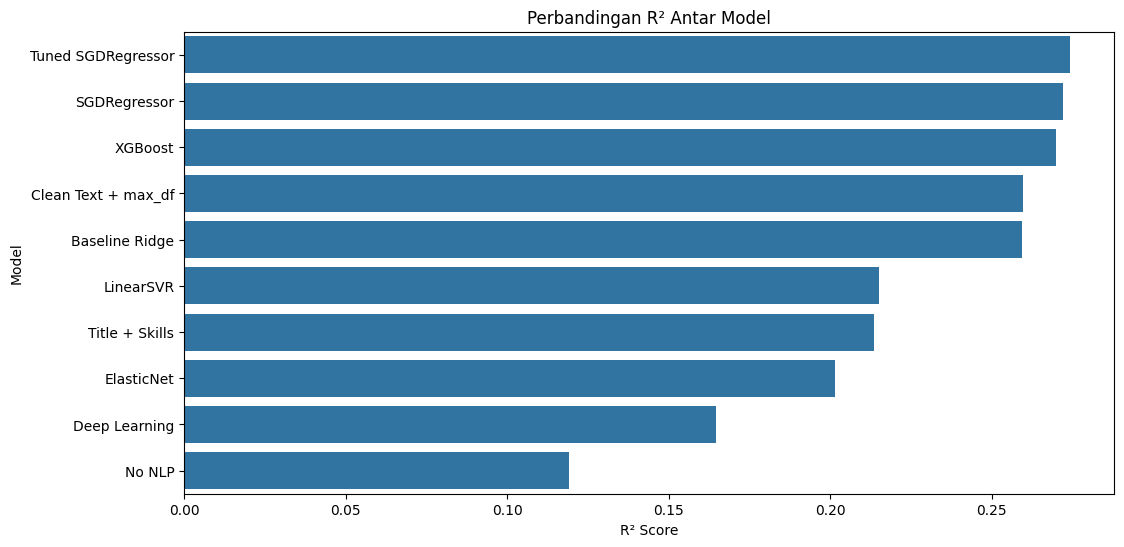

In [87]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=experiment_results_final,
    x="R2",
    y="experiment"
)

plt.title("Perbandingan R² Antar Model")
plt.xlabel("R² Score")
plt.ylabel("Model")
plt.show()

### MAE

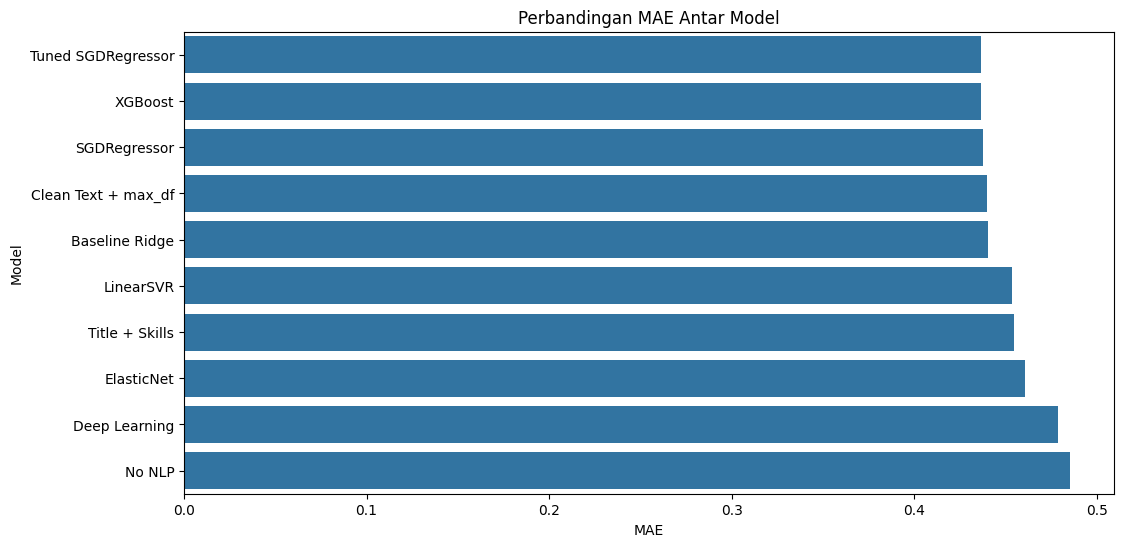

In [88]:
experiment_results_mae = experiment_results_final.sort_values(
    "MAE",
    ascending=True
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=experiment_results_mae,
    x="MAE",
    y="experiment"
)

plt.title("Perbandingan MAE Antar Model")
plt.xlabel("MAE")
plt.ylabel("Model")
plt.show()

### RMSE

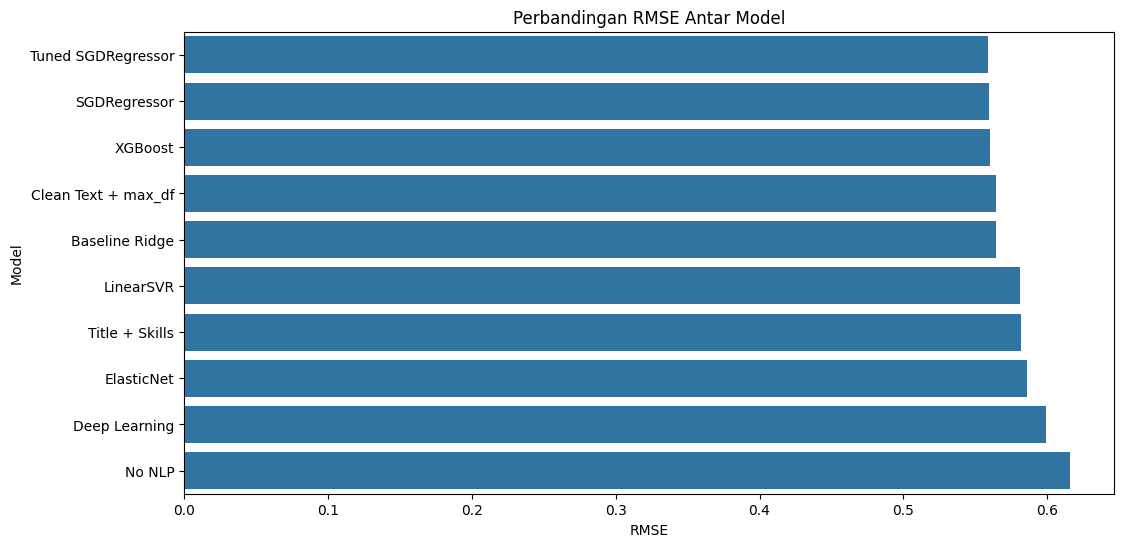

In [89]:
experiment_results_rmse = experiment_results_final.sort_values(
    "RMSE",
    ascending=True
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=experiment_results_rmse,
    x="RMSE",
    y="experiment"
)

plt.title("Perbandingan RMSE Antar Model")
plt.xlabel("RMSE")
plt.ylabel("Model")
plt.show()

### Actual vs Predicted Model Terbaik

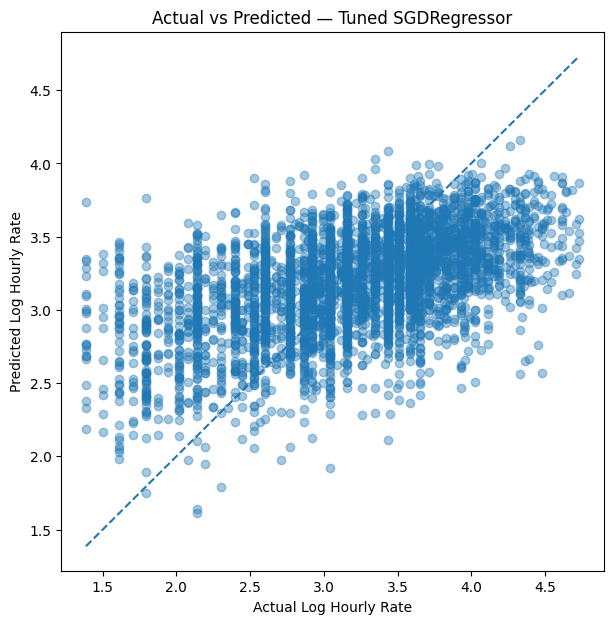

In [90]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_sgd_tuning,
    y_pred_sgd_tuned,
    alpha=0.4
)

plt.plot(
    [y_test_sgd_tuning.min(), y_test_sgd_tuning.max()],
    [y_test_sgd_tuning.min(), y_test_sgd_tuning.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted — Tuned SGDRegressor")
plt.xlabel("Actual Log Hourly Rate")
plt.ylabel("Predicted Log Hourly Rate")
plt.show()

### Residual Plot

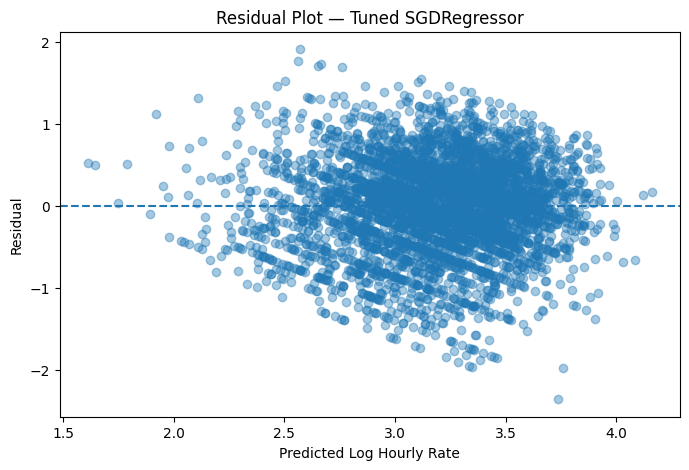

In [91]:
residuals_sgd_tuned = y_test_sgd_tuning - y_pred_sgd_tuned

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_sgd_tuned,
    residuals_sgd_tuned,
    alpha=0.4
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title("Residual Plot — Tuned SGDRegressor")
plt.xlabel("Predicted Log Hourly Rate")
plt.ylabel("Residual")
plt.show()

### Distribusi Residual

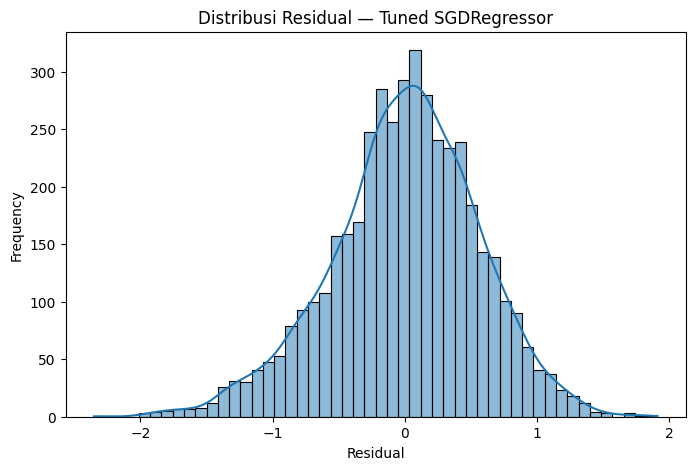

In [92]:
plt.figure(figsize=(8, 5))

sns.histplot(
    residuals_sgd_tuned,
    bins=50,
    kde=True
)

plt.title("Distribusi Residual — Tuned SGDRegressor")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

## Interpretasi Visualisasi
1. Perbandingan Performa Antar Model <BR>

Berdasarkan visualisasi perbandingan performa model menggunakan metrik MAE, RMSE, dan R², dapat dilihat bahwa model Tuned SGDRegressor memberikan performa terbaik dibandingkan model lainnya. <BR>
Model Tuned SGDRegressor memperoleh:
- `MAE = 0.436617`
- `RMSE = 0.558810`
- `R² = 0.274133` <br>

Hasil tersebut menunjukkan bahwa pendekatan sparse linear learning menggunakan TF-IDF dan SGDRegressor paling efektif dalam menangkap pola pricing pada marketplace freelance. <BR>
Selain itu, model berbasis NLP secara konsisten mengungguli model tanpa NLP. Hal ini terlihat dari perbandingan berikut:
| Model | R² |
| :--- | :--- |
| **Tuned SGDRegressor** | 0.274133 |
| **No NLP** | 0.119114 |

<br>Peningkatan tersebut menunjukkan bahwa fitur teks memiliki kontribusi besar terhadap prediksi hourly rate freelance. <br>

2. Pengaruh NLP terhadap Prediksi Harga <br>

Eksperimen menunjukkan bahwa penggunaan fitur teks meningkatkan performa model secara signifikan.
Model tanpa NLP hanya menggunakan: <br>
- `client_rating`
- `review count`
- `categorical metadata` <br>

Sedangkan model NLP menggunakan representasi TF-IDF dari deskripsi pekerjaan.
Hal ini menunjukkan bahwa:
- deskripsi pekerjaan mengandung sinyal ekonomi penting,
- pricing marketplace tidak dapat dijelaskan hanya dengan metadata sederhana
- informasi lexical pada job posting memiliki hubungan dengan hourly rate.
3. Full Text vs Title + Skills <br>

Eksperimen Title + Skills menghasilkan performa lebih rendah dibandingkan penggunaan full description.
| Model | R² |
| :--- | :--- |
| **Clean Text + max_df** | 0.259550 |
| **Title + Skills** | 0.213696 |

<br> Hal ini menunjukkan bahwa informasi pricing tidak hanya terdapat pada keyword utama, tetapi juga tersebar pada keseluruhan konteks deskripsi pekerjaan.

Deskripsi lengkap kemungkinan mengandung informasi tambahan seperti:
- tingkat kompleksitas proyek,
- ekspektasi klien,
- kebutuhan pengalaman,
- tingkat urgensi,
- dan konteks bisnis.
4. Pengaruh Text Cleaning <br>

Penerapan text cleaning ringan hanya memberikan peningkatan kecil.
| Model | R² |
| :--- | :--- |
| **Baseline Ridge** | 0.259207 |
| **Clean Text + max_df** | 0.259550 |

<br>Hal ini menunjukkan bahwa sebagian besar sinyal penting tetap dapat ditangkap meskipun teks belum dibersihkan secara agresif.

Dengan demikian, text cleaning pada dataset ini bersifat membantu tetapi bukan faktor utama peningkatan performa.

## Analisis Model
1. Mengapa SGDRegressor Menjadi Model Terbaik <br>

SGDRegressor memberikan performa terbaik karena cocok untuk:
- sparse high-dimensional TF-IDF features,
- distributed lexical signals,
- dan noisy marketplace data.
Selain itu, hasil tuning menunjukkan parameter terbaik:
```
{
 'alpha': 1e-05,
 'learning_rate': 'invscaling',
 'loss': 'squared_error',
 'penalty': 'l2'
}
```
Parameter tersebut menunjukkan bahwa:
- regularization ringan lebih cocok,
- L2 regularization lebih efektif dibanding feature selection agresif,
- dan optimization bertahap lebih stabil untuk sparse TF-IDF.

2. Mengapa ElasticNet Berkinerja Buruk <br>

ElasticNet menghasilkan performa lebih rendah dibanding Ridge dan SGDRegressor.

Hal ini menunjukkan bahwa pricing signal pada dataset tidak hanya bergantung pada sedikit keyword dominan, tetapi tersebar pada banyak token kecil.

Regularization berbasis sparsity seperti L1 menyebabkan sebagian signal lexical hilang.

Dengan demikian, distributed weak lexical signals menjadi karakteristik utama dataset.

3. Mengapa Deep Learning Tidak Unggul <br>

Model Deep Learning sederhana menghasilkan performa lebih rendah dibanding model klasik berbasis TF-IDF.
| Model | R² |
| :--- | :--- |
| **Deep Learning** | 0.164749 |
| **Tuned SGDRegressor** | 0.274133 |

<br> Hal ini kemungkinan disebabkan oleh:
- ukuran dataset yang relatif kecil,
- target pricing yang sangat noisy,
- embedding sederhana,
- dan keterbatasan semantic representation.
Hasil tersebut menunjukkan bahwa pendekatan klasik TF-IDF masih sangat kompetitif untuk task marketplace regression.



## Error Analysis
1. Overprediction pada Technical Jobs <br>

Berdasarkan error analysis, model sering melakukan overprediction pada posting pekerjaan teknikal.

Contoh keyword yang sering menghasilkan overprediction:
- `API`
- `OpenAI`
- `Analytics`
- `Blockchain`
- `SaaS`
- `Shopify`
- `Machine Learning`

Hal ini menunjukkan bahwa model belajar asosiasi:

"technical buzzword = high pricing"

Namun pada marketplace freelance, keyword teknikal tidak selalu merepresentasikan willingness-to-pay tinggi.

Banyak posting menggunakan buzzword premium tetapi tetap memiliki budget rendah.

2. Faktor yang Tidak Tersedia pada Dataset

Walaupun model terbaik berhasil mencapai R² sekitar 0.27, masih terdapat banyak faktor pricing yang tidak tersedia pada dataset.

Contohnya:
- reputasi freelancer,
- kualitas portfolio,
- company size,
- client spending history,
- proposal quality,
- tingkat urgensi,
- negotiation process,
- dan kompleksitas proyek sebenarnya.

Akibatnya, sebagian besar variasi harga tetap tidak dapat diamati oleh model.



## Feature Importance Analysis
1. Fitur Positif <br>

Beberapa keyword yang paling meningkatkan prediksi hourly rate:
- `consultant`
- `strategy`
- `senior`
- `blockchain`
- `SaaS`
- `analytics`
- `expert`
- `United States`

Keyword tersebut merepresentasikan:
- specialized expertise,
- consulting-level work,
- strategic role,
- dan niche technical domain.

2. Fitur Negatif <br>

Beberapa keyword yang paling menurunkan prediksi hourly rate:
- `virtual assistant`
- `data entry`
- `cold calling`
- `lead generation`
- `SEO`
- `Instagram`
- `WordPress`

Keyword tersebut cenderung terkait dengan:

- commoditized labor,
- outsourcing-heavy tasks,
- low-margin service,
- dan oversupplied marketplace categories.

Hasil ini menunjukkan bahwa model berhasil menangkap struktur ekonomi marketplace freelance.

## Limitasi
1. Keterbatasan Dataset <br>

Dataset tidak memiliki informasi penting seperti:
- `freelancer reputation,`
- `portfolio quality,`
- `company size,`
- `client budget,`
- `hiring urgency,`
- `dan proposal information.`

2. Keterbatasan Representasi TF-IDF <br>

TF-IDF hanya merepresentasikan frekuensi token dan belum mampu memahami semantic meaning secara mendalam.

Akibatnya, model belum mampu membedakan technical buzzword usage,dan actual market value.

3. Karakteristik Marketplace Pricing <br>

Hourly rate freelance bersifat negotiation-driven dan memiliki conditional variance tinggi.

Untuk keyword yang sama, harga dapat sangat berbeda tergantung konteks bisnis dan kualitas freelancer.

# CONCLUSION
Penelitian ini bertujuan memprediksi hourly rate freelance menggunakan pendekatan Natural Language Processing (NLP) pada deskripsi pekerjaan marketplace freelance.

Berdasarkan hasil eksperimen, penggunaan NLP berbasis TF-IDF terbukti meningkatkan performa prediksi secara signifikan dibanding model tanpa fitur teks.

Model terbaik pada penelitian ini adalah Tuned SGDRegressor dengan:
-` MAE = 0.436617`
- `RMSE = 0.558810`
- `R² = 0.274133`

Hasil tersebut menunjukkan bahwa sparse linear learning sangat efektif untuk menangani distributed lexical signals pada data marketplace freelance.

Selain itu, eksperimen menunjukkan bahwa:
- ull description lebih informatif dibanding title + skills,
- text cleaning hanya memberikan peningkatan kecil,
- ElasticNet terlalu agresif menghilangkan weak lexical signals,
- dan Deep Learning sederhana belum mampu mengungguli pendekatan klasik TF-IDF.

Penelitian ini juga menemukan bahwa keyword teknikal premium tidak selalu berkorelasi dengan harga tinggi, sehingga pricing freelance memiliki karakteristik kompleks dan noisy.

Secara keseluruhan, penelitian ini menunjukkan bahwa pendekatan NLP klasik berbasis TF-IDF dan SGDRegressor masih sangat kompetitif untuk task marketplace pricing prediction dengan dataset berukuran menengah dan target yang noisy.